In [1]:
import kagglehub
import os
import pandas as pd

# Download the latest version of the dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

print(f"Data downloaded to: {path}")

# Load the main CSV file
file_path = os.path.join(path, "diabetes.csv")
df = pd.read_csv(file_path)

print("\nFirst 5 records:")
display(df.head())

/home/adithya/Development/adithyasean/computer-vision/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data downloaded to: /home/adithya/.cache/kagglehub/datasets/uciml/pima-indians-diabetes-database/versions/1

First 5 records:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
import tensorflow as tf # tested with 1.14.0
from keras.models import Sequential # feed forward training - each node is linked with it`s predecesor
from keras.layers import Dense # nodes are fully connected across the entire NN
import numpy
import pandas as pd
#from google.colab import files
#uploaded=files.upload()

I0000 00:00:1778509299.088949   22358 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778509299.159959   22358 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778509300.646643   22358 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
model=Sequential() # commences with creating the structure of the NN, layers are connected from left to right

In [4]:
model.add(Dense(12,input_dim=8,activation='relu'))
model.add(Dense(20,activation='relu')) # hidden layer -01
model.add(Dense(20,activation='relu')) # hidden layer -02
model.add(Dense(22,activation='relu')) # hidden layer -03
model.add(Dense(1,activation='sigmoid')) # output layer

/home/adithya/Development/adithyasean/computer-vision/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1778509302.098007   22358 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


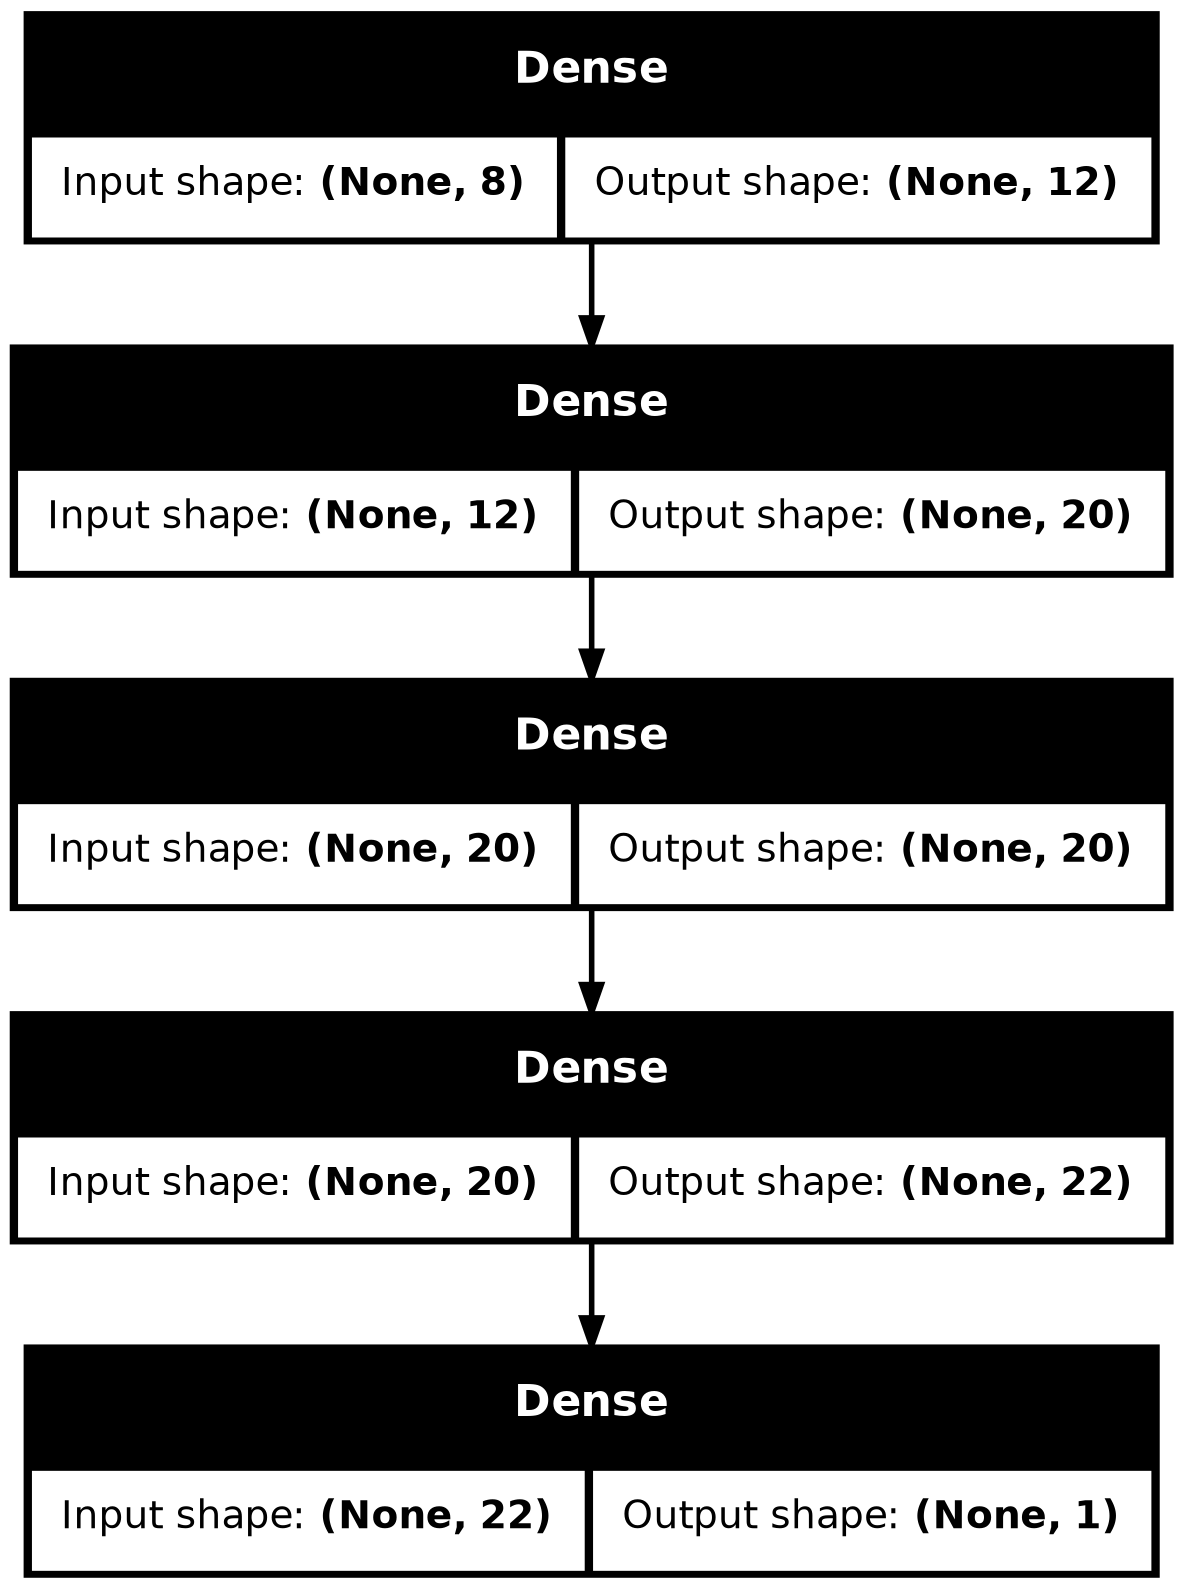

In [5]:
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=False)

In [6]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy']) # configuring your back-propergation execution

In [7]:
inputs = df.drop(['Outcome'],axis='columns') # independant dataset, excluding the dependent attibute
inputs

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [8]:
target=df.Outcome # dependant attribute

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(inputs,target,test_size=0.2) # 20% is allocated for the testing

In [10]:
model.fit(X_train,y_train,epochs=100,batch_size=10)

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5749 - loss: 1.0402
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6612 - loss: 0.6915
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6726 - loss: 0.6337
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6726 - loss: 0.6230
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6922 - loss: 0.6193
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6661 - loss: 0.6352
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6726 - loss: 0.6078
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6857 - loss: 0.5996
Epoch 9/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6987 - loss: 0.6047
Epoch 10/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7068 - loss: 0.5872
Epoch 11/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6889 - loss: 0.5970
Epoch 12/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

In [11]:
scores=model.evaluate(X_test,y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6948 - loss: 0.6373  


In [12]:
print(model.metrics_names[1],scores[1]*100)

compile_metrics 69.48052048683167


In [13]:
print(model.metrics_names[0],scores[0]*100)

loss 63.72770071029663


In [14]:
model.predict(X_test[11:22])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


array([[0.34202328],
       [0.12678248],
       [0.12769352],
       [0.71039027],
       [0.2973027 ],
       [0.99433404],
       [0.10296481],
       [0.14158574],
       [0.13074088],
       [0.7366694 ],
       [0.57298017]], dtype=float32)